# Project Cycle 3 Analysis

## Research Question

Is the proportion of current alcohol use different between male and female students?

This notebook performs the full Cycle 3 workflow:

- load the YRBS 2007 data
- define the two groups
- recode current alcohol use as a binary response
- create descriptive summaries
- run a two-proportion z-test
- save figures, tables, cleaned data, and the final interpretation
- display the figures directly in the notebook

## 1. Setup

The output folders follow the required Cycle 3 project structure. Figures will display in this notebook and will also be saved under `outputs/`.

In [1]:
%matplotlib inline

from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MPL_CACHE_DIR = PROJECT_ROOT / ".matplotlib-cache"
XDG_CACHE_DIR = PROJECT_ROOT / ".cache"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
(XDG_CACHE_DIR / "fontconfig").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import norm

RAW_DATA = PROJECT_ROOT / "data" / "raw" / "YRBS_2007.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
SUMMARY_DIR = PROJECT_ROOT / "outputs" / "summary"
REPORT_DIR = PROJECT_ROOT / "report"

for directory in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, SUMMARY_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

GROUP_COL = "WhatIsYourSex"
RESPONSE_COL = "CurrentAlcoholUse"
ALPHA = 0.05
Z_CRIT = norm.ppf(1 - ALPHA / 2)

sns.set_theme(style="whitegrid")

def fmt_num(value, digits=4):
    return f"{value:.{digits}f}"

def fmt_pct(value, digits=1):
    return f"{100 * value:.{digits}f}%"

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\TY_HONG\Desktop\project-cycle-3


## 2. Load Data and Recode Variables

Group variable:

- `WhatIsYourSex`: `1 = Female`, `2 = Male`

Response variable:

- `CurrentAlcoholUse`: code `1 = no current alcohol use`
- `CurrentAlcoholUse`: codes `2-7 = current alcohol use`

Missing values are removed from the analysis.

In [2]:
df = pd.read_csv(RAW_DATA)

selected = df[[GROUP_COL, RESPONSE_COL]].copy()
selected["sex"] = selected[GROUP_COL].map({1: "Female", 2: "Male"})
selected["current_alcohol_use"] = np.select(
    [
        selected[RESPONSE_COL].eq(1),
        selected[RESPONSE_COL].between(2, 7, inclusive="both"),
    ],
    [0, 1],
    default=np.nan,
)

cleaned = selected.dropna(subset=["sex", "current_alcohol_use"]).copy()
cleaned["current_alcohol_use"] = cleaned["current_alcohol_use"].astype(int)
cleaned = cleaned.rename(
    columns={
        GROUP_COL: "sex_code",
        RESPONSE_COL: "current_alcohol_code",
    }
)

cleaned.to_csv(PROCESSED_DIR / "cycle3_cleaned_gender_alcohol.csv", index=False)

display(Markdown(f"Original rows: **{len(df):,}**  \nRows used after cleaning: **{len(cleaned):,}**"))
cleaned.head()

Original rows: **14,041**  
Rows used after cleaning: **12,659**

,sex_code,current_alcohol_code,sex,current_alcohol_use
3,1.0,1.0,Female,0
5,1.0,1.0,Female,0
6,1.0,1.0,Female,0
7,1.0,1.0,Female,0
8,1.0,1.0,Female,0


## 3. Descriptive Summary

Before running the test, summarize the current alcohol use proportion in each group.

In [3]:
group_summary = (
    cleaned.groupby("sex", observed=True)["current_alcohol_use"]
    .agg(n="count", current_alcohol_users="sum", proportion_current_alcohol_use="mean")
    .reset_index()
)

group_summary["current_alcohol_non_users"] = (
    group_summary["n"] - group_summary["current_alcohol_users"]
)

group_summary["percent_current_alcohol_use"] = (
    100 * group_summary["proportion_current_alcohol_use"]
)

order = ["Female", "Male"]
group_summary["sex"] = pd.Categorical(
    group_summary["sex"],
    categories=order,
    ordered=True
)

group_summary = group_summary.sort_values("sex").reset_index(drop=True)

group_summary.to_csv(TABLES_DIR / "group_summary.csv", index=False)

display_summary = group_summary.copy()

display_summary["Proportion"] = display_summary[
    "proportion_current_alcohol_use"
].round(4)

display_summary["Percent"] = (
    display_summary["proportion_current_alcohol_use"] * 100
).round(1).astype(str) + "%"

display_summary = display_summary.rename(
    columns={
        "sex": "Group",
        "current_alcohol_users": "Current alcohol users",
    }
)

display_summary = display_summary[
    ["Group", "n", "Current alcohol users", "Proportion", "Percent"]
]

display_summary.to_csv(TABLES_DIR / "group_summary_display.csv", index=False)

group_summary_md = (
    "| Group | n | Current alcohol users | Proportion | Percent |\n"
    "| --- | --- | --- | --- | --- |\n"
)
for _, row in display_summary.iterrows():
    group_summary_md += (
        f"| {row['Group']} | {row['n']} | {row['Current alcohol users']} | "
        f"{row['Proportion']} | {row['Percent']} |\n"
    )
(TABLES_DIR / "group_summary.md").write_text(group_summary_md, encoding="utf-8")

display(display_summary)

,Group,n,Current alcohol users,Proportion,Percent
0,Female,6425,2864,0.4458,44.6%
1,Male,6234,2853,0.4577,45.8%


## 4. Two-Proportion Z-Test

The response variable is binary, so the correct method is a two-proportion z-test.

Hypotheses:

- Null hypothesis: `p_male - p_female = 0`
- Alternative hypothesis: `p_male - p_female != 0`

In [4]:
lookup = group_summary.set_index("sex")
x_female = float(lookup.loc["Female", "current_alcohol_users"])
n_female = float(lookup.loc["Female", "n"])
x_male = float(lookup.loc["Male", "current_alcohol_users"])
n_male = float(lookup.loc["Male", "n"])

p_female = x_female / n_female
p_male = x_male / n_male
difference = p_male - p_female

pooled = (x_male + x_female) / (n_male + n_female)
se_pooled = np.sqrt(pooled * (1 - pooled) * (1 / n_male + 1 / n_female))
z_stat = difference / se_pooled
p_value = 2 * norm.sf(abs(z_stat))

se_unpooled = np.sqrt(
    p_male * (1 - p_male) / n_male + p_female * (1 - p_female) / n_female
)
ci_low = difference - Z_CRIT * se_unpooled
ci_high = difference + Z_CRIT * se_unpooled

results = {
    "comparison": "Male - Female",
    "female_n": int(n_female),
    "male_n": int(n_male),
    "female_successes": int(x_female),
    "male_successes": int(x_male),
    "female_proportion": p_female,
    "male_proportion": p_male,
    "difference_male_minus_female": difference,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "z_statistic": z_stat,
    "p_value": p_value,
    "alpha": ALPHA,
    "reject_null": p_value < ALPHA,
}

pd.DataFrame([results]).to_csv(TABLES_DIR / "inference_results.csv", index=False)

inference_table = pd.DataFrame(
    [
        {"Result": "Female proportion", "Value": fmt_pct(p_female)},
        {"Result": "Male proportion", "Value": fmt_pct(p_male)},
        {"Result": "Difference, Male - Female", "Value": fmt_pct(difference)},
        {"Result": "95% CI", "Value": f"[{fmt_pct(ci_low)}, {fmt_pct(ci_high)}]"},
        {"Result": "z statistic", "Value": fmt_num(z_stat, 3)},
        {"Result": "p-value", "Value": fmt_num(p_value, 6)},
    ]
)

display(inference_table)

,Result,Value
0,Female proportion,44.6%
1,Male proportion,45.8%
2,"Difference, Male - Female",1.2%
3,95% CI,"[-0.5%, 2.9%]"
4,z statistic,1.344
5,p-value,0.178869


## 5. Effect Size: Relative Risk and Odds Ratio

The two-proportion z-test tells us whether the difference is statistically significant.  
Relative Risk and Odds Ratio help us describe the size of the difference.

- **Relative Risk (RR)** compares the current alcohol use proportions directly.
- **Odds Ratio (OR)** compares the odds of current alcohol use between male and female students.

Here, the comparison is **Male vs Female**.

In [5]:
male_non_users = n_male - x_male  # Male no count
female_non_users = n_female - x_female  # Female no count

risk_ratio = p_male / p_female  # Relative risk: male proportion divided by female proportion
se_log_rr = np.sqrt((1 / x_male) - (1 / n_male) + (1 / x_female) - (1 / n_female))  # SE for log(RR)
rr_low = np.exp(np.log(risk_ratio) - Z_CRIT * se_log_rr)  # Lower 95% CI for RR
rr_high = np.exp(np.log(risk_ratio) + Z_CRIT * se_log_rr)  # Upper 95% CI for RR

odds_male = x_male / male_non_users  # Male odds of current alcohol use
odds_female = x_female / female_non_users  # Female odds of current alcohol use
odds_ratio = odds_male / odds_female  # Odds ratio: male odds divided by female odds
se_log_or = np.sqrt(1 / x_male + 1 / male_non_users + 1 / x_female + 1 / female_non_users)  # SE for log(OR)
or_low = np.exp(np.log(odds_ratio) - Z_CRIT * se_log_or)  # Lower 95% CI for OR
or_high = np.exp(np.log(odds_ratio) + Z_CRIT * se_log_or)  # Upper 95% CI for OR

effect_size_results = {  # Store effect size results
    "comparison": "Male vs Female",
    "relative_risk": risk_ratio,
    "rr_ci_low": rr_low,
    "rr_ci_high": rr_high,
    "odds_ratio": odds_ratio,
    "or_ci_low": or_low,
    "or_ci_high": or_high,
}

pd.DataFrame([effect_size_results]).to_csv(TABLES_DIR / "effect_size_results.csv", index=False)  # Save effect sizes

effect_size_table = pd.DataFrame(  # Create display table
    [
        {"Measure": "Relative Risk", "Estimate": fmt_num(risk_ratio, 4), "95% CI": f"[{fmt_num(rr_low, 4)}, {fmt_num(rr_high, 4)}]"},
        {"Measure": "Odds Ratio", "Estimate": fmt_num(odds_ratio, 4), "95% CI": f"[{fmt_num(or_low, 4)}, {fmt_num(or_high, 4)}]"},
    ]
)

effect_size_md = (  # Build Markdown table without helper functions
    "| Measure | Estimate | 95% CI |\n"
    "| --- | --- | --- |\n"
    f"| Relative Risk | {fmt_num(risk_ratio, 4)} | [{fmt_num(rr_low, 4)}, {fmt_num(rr_high, 4)}] |\n"
    f"| Odds Ratio | {fmt_num(odds_ratio, 4)} | [{fmt_num(or_low, 4)}, {fmt_num(or_high, 4)}] |"
)
(TABLES_DIR / "effect_size_results.md").write_text(effect_size_md + "\n", encoding="utf-8")  # Save Markdown table

display(effect_size_table)  # Show effect size table

,Measure,Estimate,95% CI
0,Relative Risk,1.0267,"[0.9880, 1.0669]"
1,Odds Ratio,1.0492,"[0.9782, 1.1253]"


## 6. Visualization: Group Proportions

This figure compares the current alcohol use proportion for female and male students. It is displayed here and saved to `outputs/figures/current_alcohol_use_by_sex.png`.

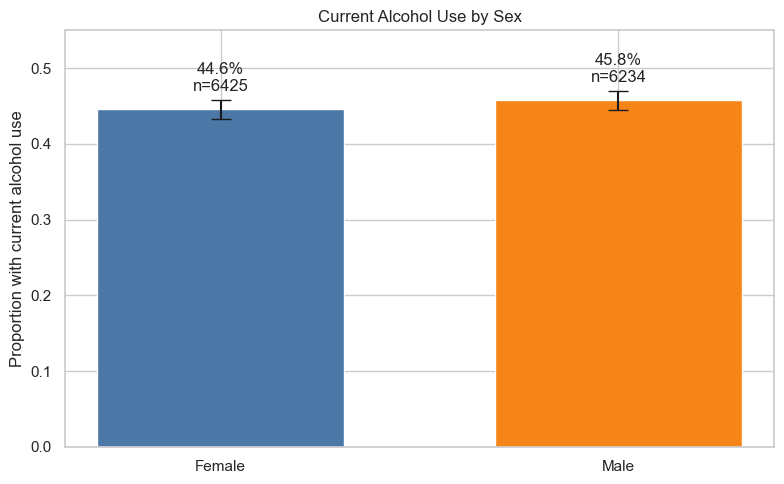

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(group_summary))
proportions = group_summary["proportion_current_alcohol_use"].to_numpy()
counts = group_summary["n"].to_numpy()
errors = Z_CRIT * np.sqrt(proportions * (1 - proportions) / counts)
colors = ["#4C78A8", "#F58518"]

ax.bar(x, proportions, yerr=errors, capsize=7, color=colors, width=0.62)
ax.set_xticks(x, group_summary["sex"])
ax.set_ylim(0, max(0.55, float((proportions + errors).max()) + 0.08))
ax.set_ylabel("Proportion with current alcohol use")
ax.set_title("Current Alcohol Use by Sex")

for xpos, prop, n in zip(x, proportions, counts):
    ax.text(xpos, prop + 0.02, f"{fmt_pct(prop)}\nn={int(n)}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "current_alcohol_use_by_sex.png", dpi=200)
plt.show()

## 7. Visualization: Confidence Interval for the Difference

This figure shows the 95% confidence interval for `p_male - p_female`. It is displayed here and saved to `outputs/figures/difference_confidence_interval.png`.

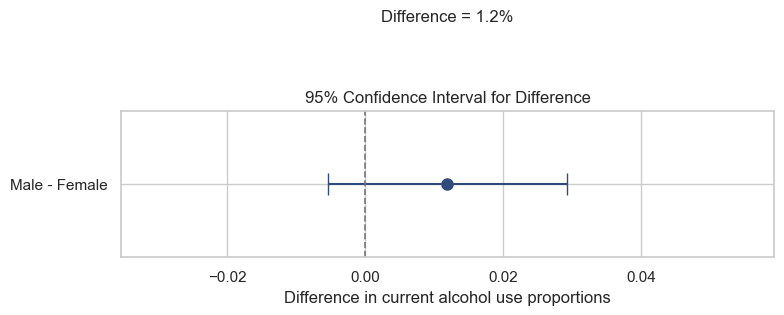

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

diff = results["difference_male_minus_female"]
low = results["ci_low"]
high = results["ci_high"]

ax.errorbar(
    diff,
    0,
    xerr=[[diff - low], [high - diff]],
    fmt="o",
    color="#2F4B7C",
    ecolor="#2F4B7C",
    capsize=8,
    markersize=8,
)
ax.axvline(0, color="#777777", linestyle="--", linewidth=1.2)
ax.set_yticks([0], ["Male - Female"])
ax.set_xlabel("Difference in current alcohol use proportions")
ax.set_title("95% Confidence Interval for Difference")
padding = max(0.03, (high - low) * 0.4)
ax.set_xlim(low - padding, high + padding)
ax.text(diff, 0.12, f"Difference = {fmt_pct(diff)}", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "difference_confidence_interval.png", dpi=200)
plt.show()

## 8. One-Slide Infographic Summary

This creates the required one-slide exhibition summary. It is displayed here and saved to `outputs/summary/one_slide_infographic_summary.png`.

## 9. Final Interpretation

In [8]:
if results["difference_male_minus_female"] > 0:
    direction_sentence = "male students had a higher observed proportion of current alcohol use than female students"
else:
    direction_sentence = "male students had a lower observed proportion of current alcohol use than female students"

if results["reject_null"]:
    test_sentence = "Because the p-value is below 0.05, we reject the null hypothesis."
    conclusion_sentence = "There is statistical evidence that the proportion of current alcohol use differs between male and female students."
else:
    test_sentence = "Because the p-value is not below 0.05, we fail to reject the null hypothesis."
    conclusion_sentence = "There is not enough statistical evidence to conclude that the proportion of current alcohol use differs between male and female students."

rr_sentence = f"The relative risk was {fmt_num(risk_ratio, 4)}, meaning the male current alcohol use proportion was about {fmt_num(risk_ratio, 2)} times the female proportion."  # RR interpretation
or_sentence = f"The odds ratio was {fmt_num(odds_ratio, 4)}, meaning the odds of current alcohol use were slightly higher for male students than for female students."  # OR interpretation

report = f"""# Final Interpretation

## Research Question

Is the proportion of current alcohol use different between male and female students?

## Method

The response variable was recoded as binary:

- `1 = current alcohol use`
- `0 = no current alcohol use`

Because the response variable is binary and the group variable has two independent groups, a two-proportion z-test was used. As an additional effect size analysis, relative risk and odds ratio were also calculated for male students compared with female students.

## Results

- Female sample size: {results['female_n']}
- Male sample size: {results['male_n']}
- Female current alcohol use proportion: {fmt_num(results['female_proportion'], 4)} ({fmt_pct(results['female_proportion'])})
- Male current alcohol use proportion: {fmt_num(results['male_proportion'], 4)} ({fmt_pct(results['male_proportion'])})
- Difference, male minus female: {fmt_num(results['difference_male_minus_female'], 4)} ({fmt_pct(results['difference_male_minus_female'])})
- 95% confidence interval: [{fmt_num(results['ci_low'], 4)}, {fmt_num(results['ci_high'], 4)}]
- z statistic: {fmt_num(results['z_statistic'], 4)}
- p-value: {fmt_num(results['p_value'], 6)}
- Relative risk, male vs female: {fmt_num(risk_ratio, 4)}; 95% CI: [{fmt_num(rr_low, 4)}, {fmt_num(rr_high, 4)}]
- Odds ratio, male vs female: {fmt_num(odds_ratio, 4)}; 95% CI: [{fmt_num(or_low, 4)}, {fmt_num(or_high, 4)}]

## Conclusion at alpha = 0.05

{test_sentence}

In this sample, {direction_sentence}. {conclusion_sentence}

{rr_sentence} {or_sentence} Both effect size estimates are close to 1, which suggests that the practical difference between male and female students is small.

This result should be interpreted as an association in survey data, not as evidence that sex causes alcohol use behavior.
"""

(REPORT_DIR / "final_interpretation.md").write_text(report, encoding="utf-8")
(SUMMARY_DIR / "analysis_summary.md").write_text(report, encoding="utf-8")

display(Markdown(report))

# Final Interpretation

## Research Question

Is the proportion of current alcohol use different between male and female students?

## Method

The response variable was recoded as binary:

- `1 = current alcohol use`
- `0 = no current alcohol use`

Because the response variable is binary and the group variable has two independent groups, a two-proportion z-test was used. As an additional effect size analysis, relative risk and odds ratio were also calculated for male students compared with female students.

## Results

- Female sample size: 6425
- Male sample size: 6234
- Female current alcohol use proportion: 0.4458 (44.6%)
- Male current alcohol use proportion: 0.4577 (45.8%)
- Difference, male minus female: 0.0119 (1.2%)
- 95% confidence interval: [-0.0054, 0.0292]
- z statistic: 1.3442
- p-value: 0.178869
- Relative risk, male vs female: 1.0267; 95% CI: [0.9880, 1.0669]
- Odds ratio, male vs female: 1.0492; 95% CI: [0.9782, 1.1253]

## Conclusion at alpha = 0.05

Because the p-value is not below 0.05, we fail to reject the null hypothesis.

In this sample, male students had a higher observed proportion of current alcohol use than female students. There is not enough statistical evidence to conclude that the proportion of current alcohol use differs between male and female students.

The relative risk was 1.0267, meaning the male current alcohol use proportion was about 1.03 times the female proportion. The odds ratio was 1.0492, meaning the odds of current alcohol use were slightly higher for male students than for female students. Both effect size estimates are close to 1, which suggests that the practical difference between male and female students is small.

This result should be interpreted as an association in survey data, not as evidence that sex causes alcohol use behavior.


## 10. Saved Outputs

This final cell lists the files created by the notebook.

In [ ]:
saved_files = [
    PROCESSED_DIR / "cycle3_cleaned_gender_alcohol.csv",
    TABLES_DIR / "group_summary.csv",
    TABLES_DIR / "group_summary.md",
    TABLES_DIR / "inference_results.csv",
    TABLES_DIR / "effect_size_results.csv",
    TABLES_DIR / "effect_size_results.md",
    FIGURES_DIR / "current_alcohol_use_by_sex.png",
    FIGURES_DIR / "difference_confidence_interval.png",
    SUMMARY_DIR / "analysis_summary.md",
    REPORT_DIR / "final_interpretation.md",
]

for path in saved_files:
    print(path.relative_to(PROJECT_ROOT))

data\processed\cycle3_cleaned_gender_alcohol.csv
outputs\tables\group_summary.csv
outputs\tables\group_summary.md
outputs\tables\inference_results.csv
outputs\tables\effect_size_results.csv
outputs\tables\effect_size_results.md
outputs\figures\current_alcohol_use_by_sex.png
outputs\figures\difference_confidence_interval.png
outputs\summary\one_slide_infographic_summary.png
outputs\summary\analysis_summary.md
report\final_interpretation.md
